In [87]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import ImageFile 
ImageFile.LOAD_TRUNCATED_IMAGES = True


In [88]:
work_dir = os.getcwd()
work_dir

'/workspaces/XrayFractureClass/jupytr_notebooks'

In [89]:
my_data_dir = '/workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification'
train_path = my_data_dir + '/train'
val_path = my_data_dir + '/val'
test_path = my_data_dir + '/test'
print (train_path)
print(os.path.exists(train_path))

/workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train
True


In [90]:
version = 'v1'
file_path = f'outputs/{version}'

if 'outputs' in os.listdir(work_dir) and version in os.listdir(work_dir + '/outputs'):
    print('Old version is already available create a new version.')
    pass
else:
    os.makedirs(name=file_path)

Old version is already available create a new version.


In [91]:
labels = os.listdir(train_path)
print(f"Project Labels: {labels}")

Project Labels: ['fractured', 'not fractured']


In [92]:
import joblib
version = 'v2'
file_path = f'/workspaces/XrayFractureClass/outputs/{version}'
os.makedirs (file_path, exist_ok=True )

image_shape = (224, 224, 3)

joblib.dump(value=image_shape, filename=f'{file_path}/image_shape.pkl')
image_shape = joblib.load(filename=f'{file_path}/image_shape.pkl')
print (f'image_shape : {image_shape}')

image_shape : (224, 224, 3)


* train - fractured: 4606 images
* train - not fractured: 4640 images
* val - fractured: 337 images
* val - not fractured: 492 images
* test - fractured: 238 images
* test - not fractured: 268 images




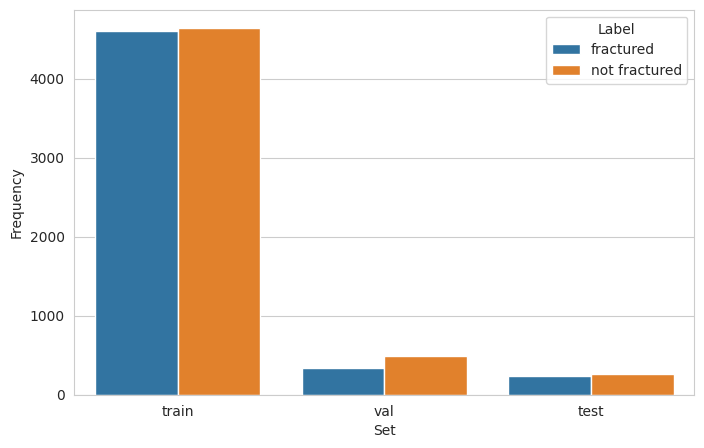

In [93]:
labels = ['fractured', 'not fractured']
file_path = '/workspaces/XrayFractureClass/outputs/v2'
df_freq = pd.DataFrame([])

for folder in ['train', 'val', 'test']:
    for label in labels:
        freq = int(len(os.listdir(my_data_dir + '/' + folder + '/' + label)))
        
        df_freq = pd.concat([df_freq, pd.DataFrame([{'Set': folder, 'Label': label, 'Frequency': freq}])  
        ], ignore_index = True)

        print(
            f"* {folder} - {label}: {len(os.listdir(my_data_dir+'/'+ folder + '/' + label))} images")

print("\n")
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label')
plt.savefig(f'{file_path}/labels_distribution.png',
            bbox_inches='tight', dpi=150)
plt.show()

In [94]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [95]:
augmented_image_data = ImageDataGenerator(rotation_range=20,
                                          width_shift_range=0.10,
                                          height_shift_range=0.10,
                                          shear_range=0.1,
                                          zoom_range=0.1,
                                          horizontal_flip=True,
                                          vertical_flip=True,
                                          fill_mode='nearest',
                                          rescale=1./255
                                          )

In [96]:
batch_size = 20  # Set batch size
train_set = augmented_image_data.flow_from_directory(train_path,
                                                     target_size=image_shape[:2],
                                                     color_mode='rgb',
                                                     batch_size=batch_size,
                                                     class_mode='binary',
                                                     shuffle=True
                                                     )

train_set.class_indices

Found 9246 images belonging to 2 classes.


{'fractured': 0, 'not fractured': 1}

In [97]:
validation_set = ImageDataGenerator(rescale=1./255).flow_from_directory(val_path,
                                                                        target_size=image_shape[:2],
                                                                        color_mode='rgb',
                                                                        batch_size=batch_size,
                                                                        class_mode='binary',
                                                                        shuffle=False
                                                                        )

validation_set.class_indices

Found 829 images belonging to 2 classes.


{'fractured': 0, 'not fractured': 1}

In [98]:
test_set = ImageDataGenerator(rescale=1./255).flow_from_directory(test_path,
                                                                  target_size=image_shape[:2],
                                                                  color_mode='rgb',
                                                                  batch_size=batch_size,
                                                                  class_mode='binary',
                                                                  shuffle=False
                                                                  )

test_set.class_indices

Found 506 images belonging to 2 classes.


{'fractured': 0, 'not fractured': 1}

(20, 224, 224, 3)


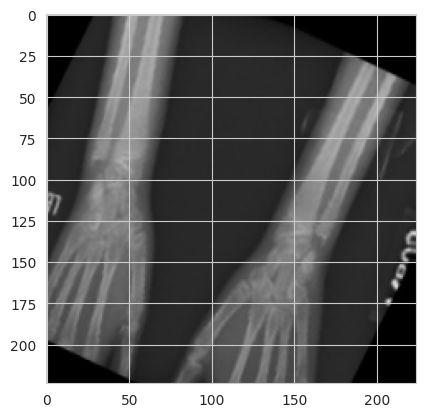

(20, 224, 224, 3)


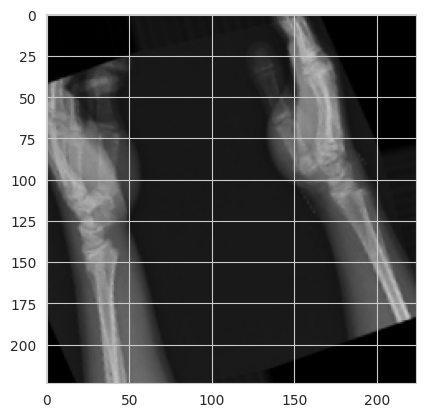

(20, 224, 224, 3)


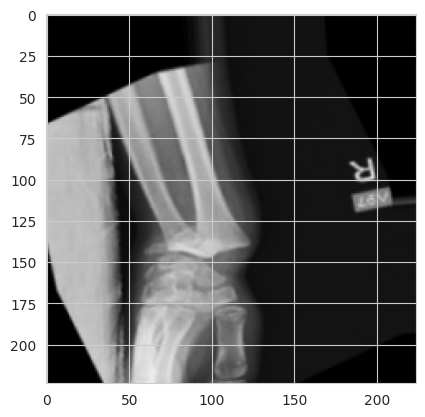

In [99]:
for _ in range(3):
    img, label = next (train_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()

(20, 224, 224, 3)


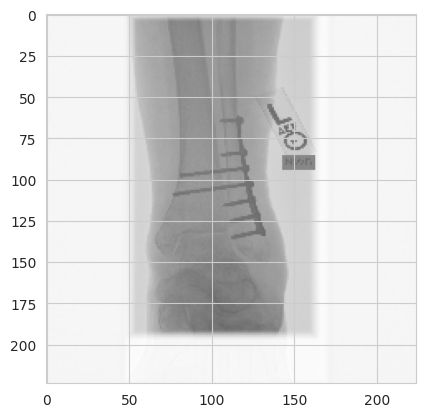

(20, 224, 224, 3)


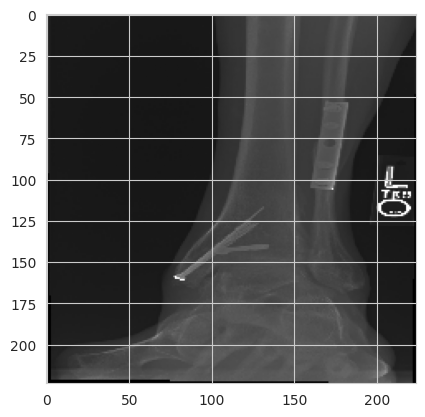

(20, 224, 224, 3)


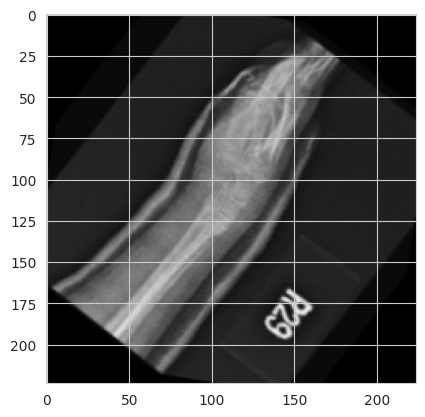

(20, 224, 224, 3)


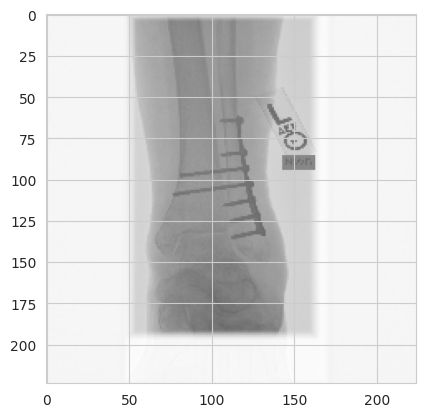

(20, 224, 224, 3)


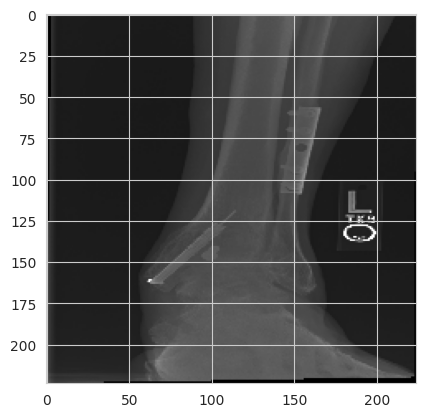

(20, 224, 224, 3)


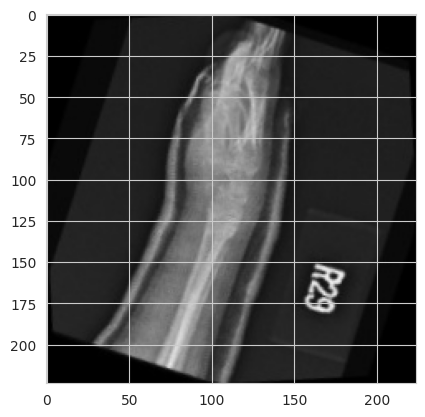

In [100]:
for _ in range(3):
    img, label = next(validation_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()
for _ in range(3):
    img, label = next(test_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()

In [101]:
joblib.dump(value=train_set.class_indices,
            filename=f"{file_path}/class_indices.pkl")

['/workspaces/XrayFractureClass/outputs/v2/class_indices.pkl']

In [102]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D

In [103]:
def create_tf_model_v2():
    model = Sequential()

    model.add(Conv2D(filters=32, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=64, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=128, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=128, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))    

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))

    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    return model

In [104]:
create_tf_model_v2().summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [105]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [106]:
model_v2 = create_tf_model_v2()
model_v2.fit(train_set,
          epochs=8,
          steps_per_epoch=len(train_set.classes) // batch_size,
          validation_data=validation_set,
          callbacks=[early_stop],
          verbose=1
          )

#import tensorflow as tf
#model = tf.keras.models.load_model(f'{file_path_v2}/fracture_detection_model_v2.keras')
#print('Model loaded successfully')

Epoch 1/8
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 876ms/step - accuracy: 0.6007 - loss: 0.6644

/usr/local/python/3.12.1/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


462/462 ━━━━━━━━━━━━━━━━━━━━ 423s 908ms/step - accuracy: 0.6392 - loss: 0.6394 - val_accuracy: 0.6888 - val_loss: 0.6171
Epoch 2/8
  1/462 ━━━━━━━━━━━━━━━━━━━━ 4:32 590ms/step - accuracy: 0.7000 - loss: 0.4976

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


462/462 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.7000 - loss: 0.4976 - val_accuracy: 0.7045 - val_loss: 0.6092
Epoch 3/8
462/462 ━━━━━━━━━━━━━━━━━━━━ 398s 861ms/step - accuracy: 0.7253 - loss: 0.5519 - val_accuracy: 0.7008 - val_loss: 0.5600
Epoch 4/8
462/462 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.7000 - loss: 0.6800 - val_accuracy: 0.6888 - val_loss: 0.5730
Epoch 5/8
462/462 ━━━━━━━━━━━━━━━━━━━━ 385s 784ms/step - accuracy: 0.7864 - loss: 0.4740 - val_accuracy: 0.8408 - val_loss: 0.3803
Epoch 6/8
462/462 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8000 - loss: 0.3883 - val_accuracy: 0.8432 - val_loss: 0.3802
Epoch 7/8
462/462 ━━━━━━━━━━━━━━━━━━━━ 373s 792ms/step - accuracy: 0.8320 - loss: 0.3845 - val_accuracy: 0.8794 - val_loss: 0.2989
Epoch 8/8
462/462 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.7500 - loss: 0.4395 - val_accuracy: 0.8661 - val_loss: 0.3130


In [107]:
model_v2.save(f'{file_path}/fracture_detection_model_v2.keras')
print ('The model has been saved')

The model has been saved


In [108]:
history = pd.DataFrame(model_v2.history.history)
history.head()

,accuracy,loss,val_accuracy,val_loss
0,0.639172,0.639440,0.688782,0.617096
1,0.700000,0.497614,0.704463,0.609162
2,0.725341,0.551947,0.700844,0.559960
3,0.700000,0.680045,0.688782,0.572996
4,0.786365,0.473991,0.840772,0.380264


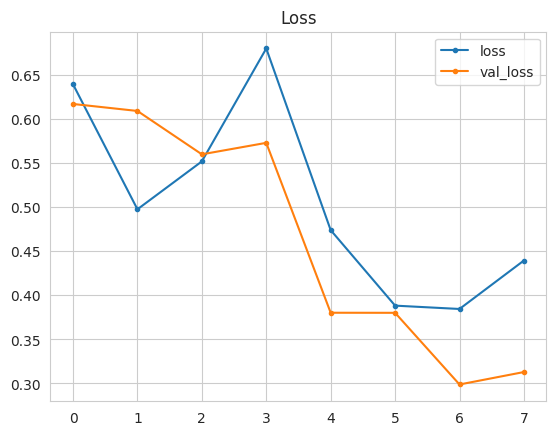

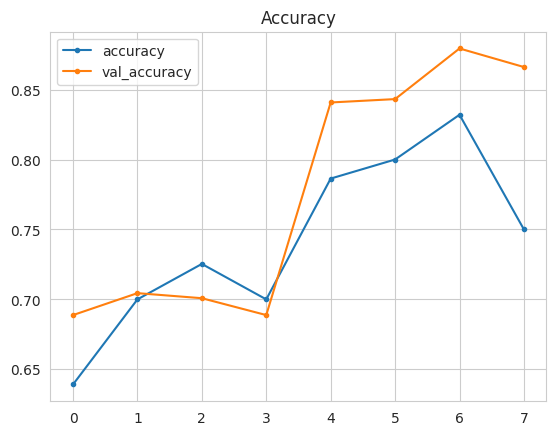

In [109]:
sns.set_style("whitegrid")
history[['loss','val_loss']].plot(style='.-')
plt.title("Loss")
plt.show()

print("\n")
history[['accuracy','val_accuracy']].plot(style='.-')
plt.title("Accuracy")
plt.show()

In [110]:
loss, accuracy = model_v2.evaluate(test_set)
print (f'Test Loss = :{loss:.4f}')
print (f'Test Accuracy = :{accuracy:.4f}')

26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 338ms/step - accuracy: 0.8221 - loss: 0.3642
Test Loss = :0.3642
Test Accuracy = :0.8221


#### Train Set #### 

463/463 ━━━━━━━━━━━━━━━━━━━━ 170s 366ms/step
---  Confusion Matrix  ---
                         Actual fractured  Actual not fractured
Predicted fractured                  1819                  2787
Predicted not fractured              1872                  2768


---  Classification Report  ---
               precision    recall  f1-score   support

    fractured       0.49      0.39      0.44      4606
not fractured       0.50      0.60      0.54      4640

     accuracy                           0.50      9246
    macro avg       0.50      0.50      0.49      9246
 weighted avg       0.50      0.50      0.49      9246
 



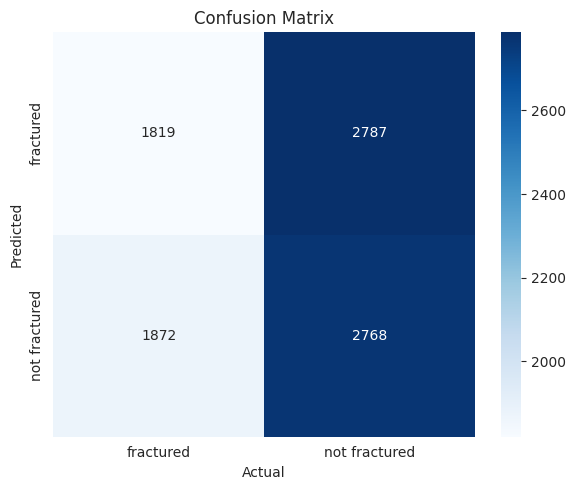

#### Validation Set #### 

12/42 ━━━━━━━━━━━━━━━━━━━━ 10s 338ms/step

/usr/local/python/3.12.1/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 303ms/step
---  Confusion Matrix  ---
                         Actual fractured  Actual not fractured
Predicted fractured                   255                    82
Predicted not fractured                29                   463


---  Classification Report  ---
               precision    recall  f1-score   support

    fractured       0.90      0.76      0.82       337
not fractured       0.85      0.94      0.89       492

     accuracy                           0.87       829
    macro avg       0.87      0.85      0.86       829
 weighted avg       0.87      0.87      0.86       829
 



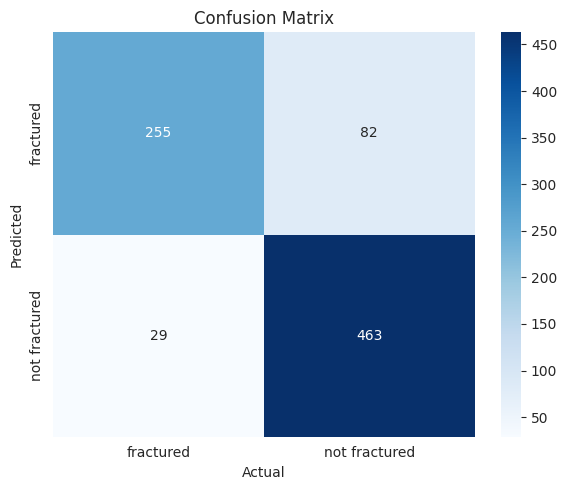

#### Test Set ####

26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 340ms/step
---  Confusion Matrix  ---
                         Actual fractured  Actual not fractured
Predicted fractured                   176                    62
Predicted not fractured                28                   240


---  Classification Report  ---
               precision    recall  f1-score   support

    fractured       0.86      0.74      0.80       238
not fractured       0.79      0.90      0.84       268

     accuracy                           0.82       506
    macro avg       0.83      0.82      0.82       506
 weighted avg       0.83      0.82      0.82       506
 



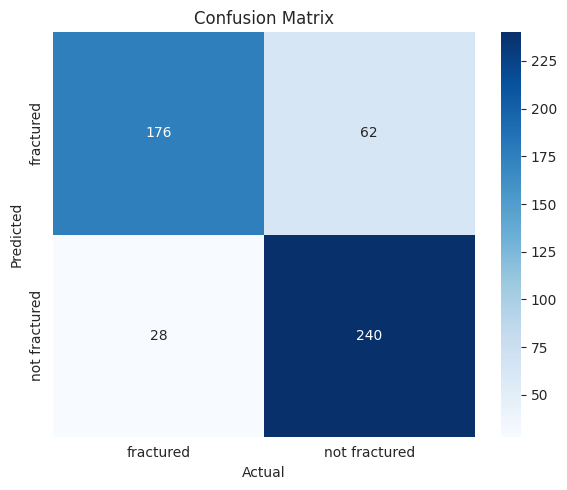

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def confusion_matrix_and_report(data_set, pipeline, label_map, set_name=''):
    data_set.reset()

    prediction = pipeline.predict(data_set)
    prediction = (prediction > 0.5). astype(int).flatten()
    y = data_set.classes

    # Compute confusion matrix
    cm = confusion_matrix(y_true=y, y_pred=prediction)

    print('---  Confusion Matrix  ---')
    print(pd.DataFrame(
        cm,
        columns=["Actual " + sub for sub in label_map],
        index=["Predicted " + sub for sub in label_map]))
    
    print("\n")

    print('---  Classification Report  ---')
    print(classification_report(y, prediction, target_names=label_map), "\n")

    # 🔹 Plot heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_map,
        yticklabels=label_map
    )

    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'/workspaces/XrayFractureClass/outputs/v2/confusion_matrix_{set_name}.png', bbox_inches = 'tight', dpi=150)
    plt.show()
    
def clf_performance(train_set, validation_set, test_set, pipeline, label_map):
  """
  Print classification performance
  """
  print("#### Train Set #### \n")
  confusion_matrix_and_report(train_set, pipeline, label_map, 'Train set')

  print("#### Validation Set #### \n")
  confusion_matrix_and_report(validation_set, pipeline, label_map, 'Validation set')

  print("#### Test Set ####\n")
  confusion_matrix_and_report(test_set, pipeline, label_map, 'Test Set')

class_names = list(test_set.class_indices.keys())
clf_performance( train_set, validation_set, test_set, model_v2, class_names)